# Allen–Cahn vs Cahn–Hilliard Dynamics

Two classic phase-field PDEs use the same double-well potential but different conservation laws:
$$
\partial_t u = \varepsilon^2 \Delta u - (u^3-u) \quad \text{(Allen–Cahn)},
$$
$$
\partial_t u = \Delta\!\left(-\varepsilon^2 \Delta u + (u^3-u)\right) \quad \text{(Cahn–Hilliard)}.
$$
Allen–Cahn is non-conservative; Cahn–Hilliard conserves mass.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/allen-cahn-cahn-hilliard") if Path("python/allen-cahn-cahn-hilliard").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Spectral discretization in 1D

We evolve both models from the same random initial state and compare coarsening behavior.


In [2]:
n = 256
L = 2*np.pi
x = np.linspace(0, L, n, endpoint=False)
dx = x[1]-x[0]
k = 2*np.pi*np.fft.fftfreq(n, d=dx)
k2 = k**2
k4 = k2**2

rng = np.random.default_rng(0)
u0 = 0.15*rng.standard_normal(n)
eps = 0.045
dt = 0.015
n_steps = 260
snap_ids = [0, 40, 120, 260]

u_ac = u0.copy()
u_ch = u0.copy()
snaps_ac = []
snaps_ch = []

for tstep in range(n_steps + 1):
    if tstep in snap_ids:
        snaps_ac.append((tstep, u_ac.copy()))
        snaps_ch.append((tstep, u_ch.copy()))

    # Allen-Cahn: explicit nonlinearity + implicit Laplacian
    f_ac = u_ac**3 - u_ac
    U = np.fft.fft(u_ac - dt*f_ac)
    U /= (1 + dt*eps**2*k2)
    u_ac = np.fft.ifft(U).real

    # Cahn-Hilliard: explicit cubic term, implicit bi-Laplacian part
    f_ch = u_ch**3 - u_ch
    Uc = np.fft.fft(u_ch - dt*(-k2)*np.fft.fft(f_ch).real*0 + 0)  # placeholder for clarity
    # equivalent update in Fourier directly:
    Uc = np.fft.fft(u_ch) - dt*(k2)*np.fft.fft(f_ch)
    Uc /= (1 + dt*eps**2*k4)
    u_ch = np.fft.ifft(Uc).real
    u_ch -= u_ch.mean() - u0.mean()


## Compare temporal snapshots

We display both evolutions at matching times to highlight conservative vs non-conservative dynamics.


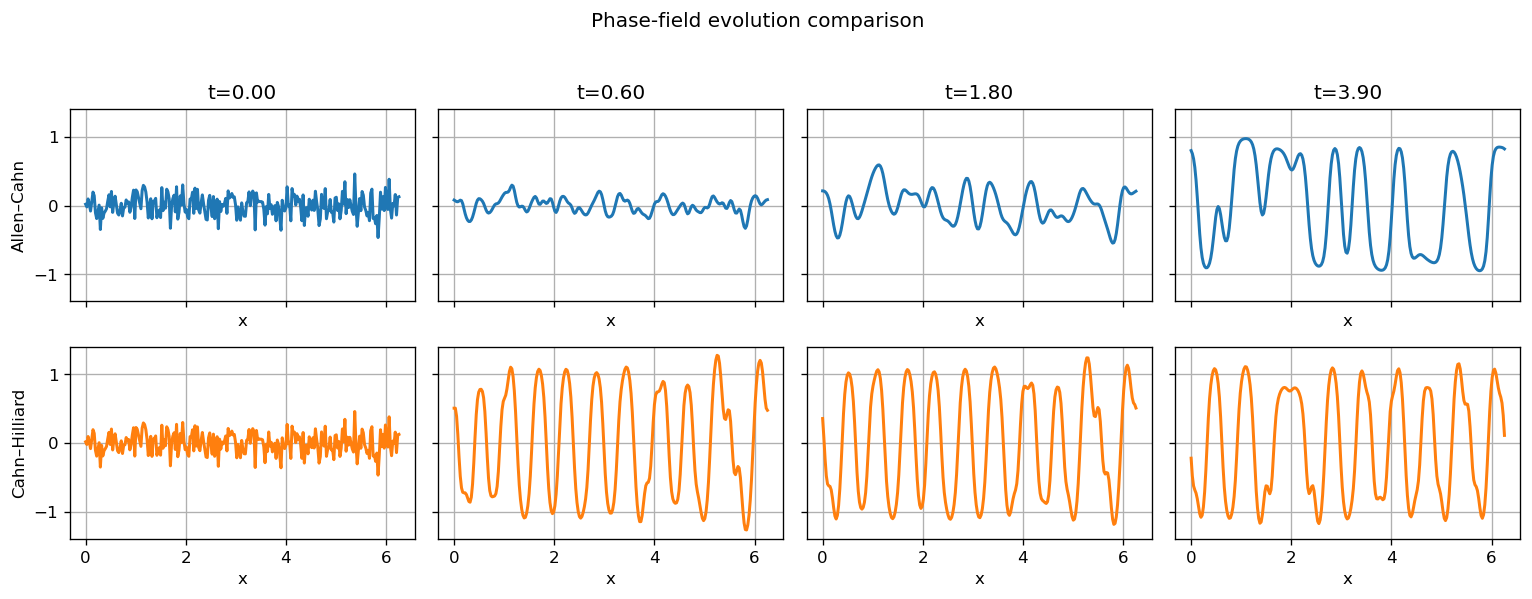

In [3]:
fig, axes = plt.subplots(2, len(snap_ids), figsize=(13, 4.8), sharex=True, sharey=True)
for j, (kstep, u) in enumerate(snaps_ac):
    axes[0, j].plot(x, u, lw=1.8)
    axes[0, j].set_title(f"t={kstep*dt:.2f}")
for j, (_, u) in enumerate(snaps_ch):
    axes[1, j].plot(x, u, lw=1.8, color="tab:orange")

axes[0, 0].set_ylabel("Allen–Cahn")
axes[1, 0].set_ylabel("Cahn–Hilliard")
for ax in axes.ravel():
    ax.set_xlabel("x")

fig.suptitle("Phase-field evolution comparison", y=1.03)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- C. Villani, *Topics in Optimal Transportation*.
- G. Peyré and M. Cuturi, *Computational Optimal Transport*.
- J. D. Murray, *Mathematical Biology* (for pattern-forming PDEs).
- R. J. LeVeque, *Finite Difference Methods for ODEs and PDEs*.
